In [1]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')


Mounted at /content/drive


# **'VGG19': VGG19**

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
80134624/80134624 [==============================] - 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.44999998807907104, Epochs: 58
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.6000000238418579, Epochs: 70
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5, Epochs: 60
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.3499999940395355, Epochs: 52
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 58
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 53
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 53
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5, Epochs: 53
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Le

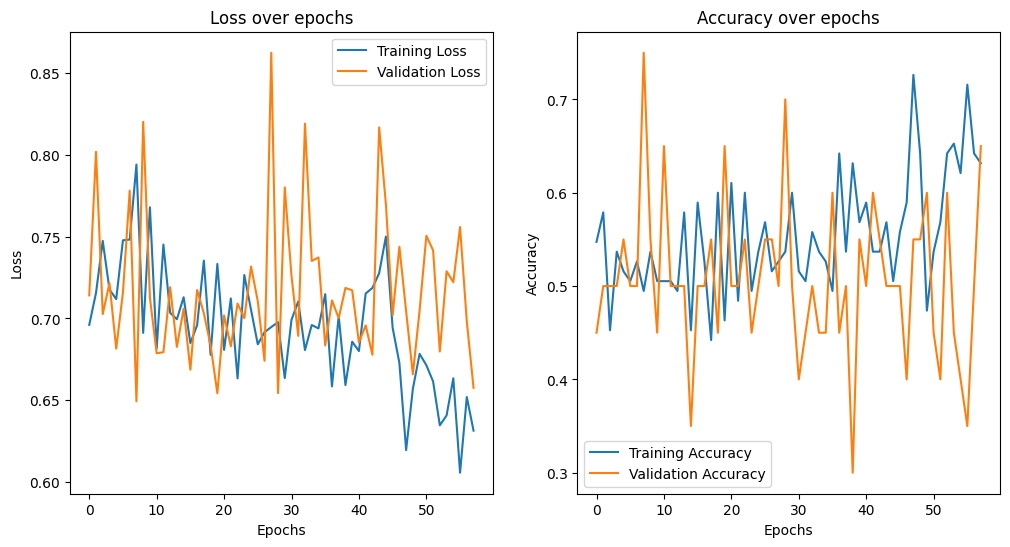

6/6 [==============================] - 2s 252ms/step
Weighted Precision: 0.2722117202268431
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.35776397515527947
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.2608695652173913
Macro Recall: 0.5
Macro F1 Score: 0.3428571428571428
Precision (None): [0.         0.52173913]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.68571429]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['4o_zararsız_graf', '4o_zararlı_graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'VGG19': VGG19
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsVGG19.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


# **vgg 16**

Found 99 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
58889256/58889256 [==============================] - 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.44999998807907104, Epochs: 51
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 51
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.550000011920929, Epochs: 61
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.550000011920929, Epochs: 63
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 58
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5, Epochs: 58
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.699999988079071, Epochs: 98
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.550000011920929, Epochs: 58
Model: VGG16, Activation: r

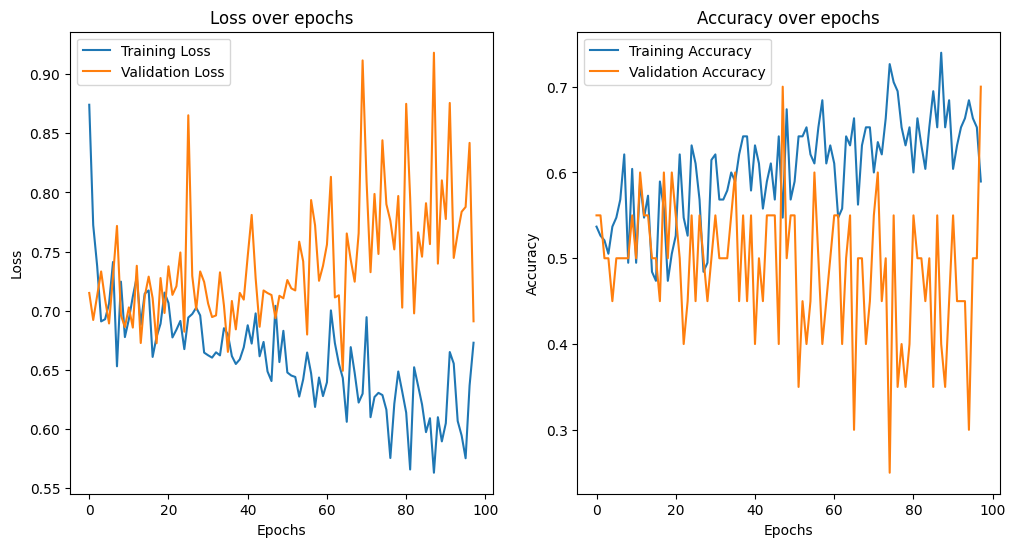

6/6 [==============================] - 2s 247ms/step
Weighted Precision: 0.2722117202268431
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.35776397515527947
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.2608695652173913
Macro Recall: 0.5
Macro F1 Score: 0.3428571428571428
Precision (None): [0.         0.52173913]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.68571429]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 200  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'VGG16': VGG16
}

results_file = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf/training_resultsVGG16.json'

# Check if results file exists and is not empty
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    # Define callbacks
                    early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
                    model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        callbacks=[early_stopping, model_checkpoint],
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    num_epochs = len(history.history['loss'])  # Number of epochs trained
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history,
                        'num_epochs': num_epochs  # Add number of epochs to result
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Saved output tensor

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Recreate the best model using the saved output tensor
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Use the saved output tensor

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Load the best model weights
best_model.load_weights('best_model.h5')

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
